## Final Model Selection

### Gradient Boosting — Primary Model
- Best probability calibration — Brier score 0.2212
- Best precision (29.04%) and accuracy (62.98%)
- Ranked 1st in McNemar's pairwise significance tests
- Monotonicity validated on 235,399 active loans

### Logistic Regression — Interpretability Model
- Highest F1 (0.412) and ROC-AUC (70.06%)
- Directly explainable coefficients — regulatory audit ready
- Retained for SHAP analysis and feature attribution

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd 
import shap 

In [62]:
import joblib
preprocessing = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Ct_for_preprocessing')


lr = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_lr_model')
gb = joblib.load(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Final_gb_model')

In [104]:
# Evaluation processed data 
X_test = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase4_Models_evalutaion\Evaluation_Ready_data.csv')
X_test = X_test.iloc[:,1:]

y_test = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\Evaluation_Ready_data_labels.csv')
y_test = y_test.iloc[:,1:]

# Tree Explainer

In [6]:
explainer = shap.TreeExplainer(gb)
shap_values_gb = explainer(X_test)

In [8]:
shapley_val = shap_values_gb.values
base_val = shap_values_gb.base_values[0]
feature_data = shap_values_gb.data

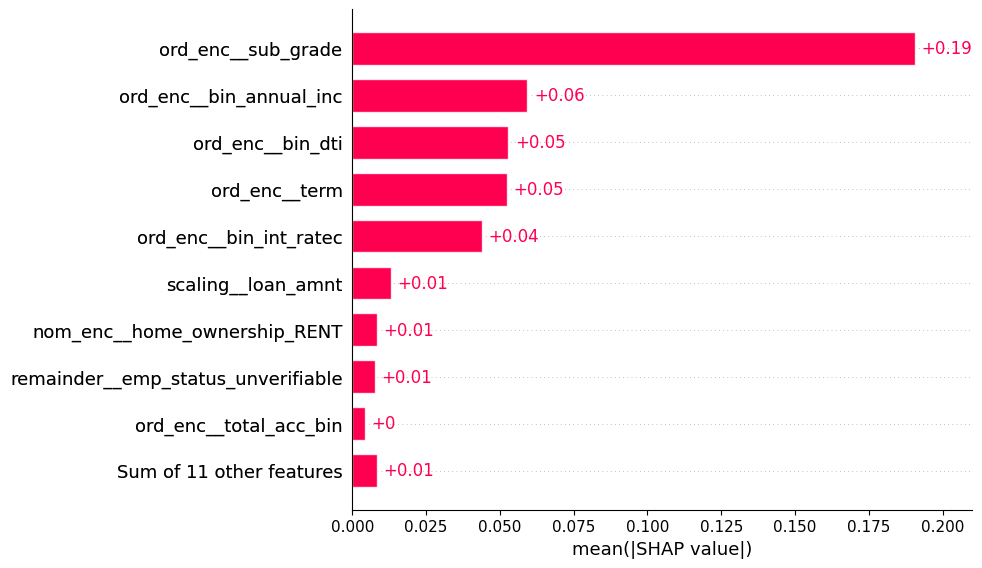

In [15]:
# Bar plot 
shap.plots.bar(shap_values_gb, max_display=10)

## GBM — SHAP Bar Plot (Global Feature Importance)

- **sub_grade (0.19)** — dominant feature, 3× more important
  than any other — model relies almost entirely on credit grade
- **bin_annual_inc, bin_dti, term (0.05-0.06)** — second tier,
  roughly equal contribution — income, debt burden and loan
  duration together form the supporting risk signal
- **bin_int_rate (0.04)** — surprisingly lower than sub_grade
  despite high feature importance in Phase 3 — GBM captures
  the risk through sub_grade directly, reducing int_rate's
  marginal contribution
- **loan_amnt, home_ownership_RENT, emp_status_unverifiable (0.01)**
  — minor contributors, consistent with EDA findings
- **total_acc_bin (0.00)** — zero contribution — model found
  no useful signal, confirms EDA finding of weak predictor

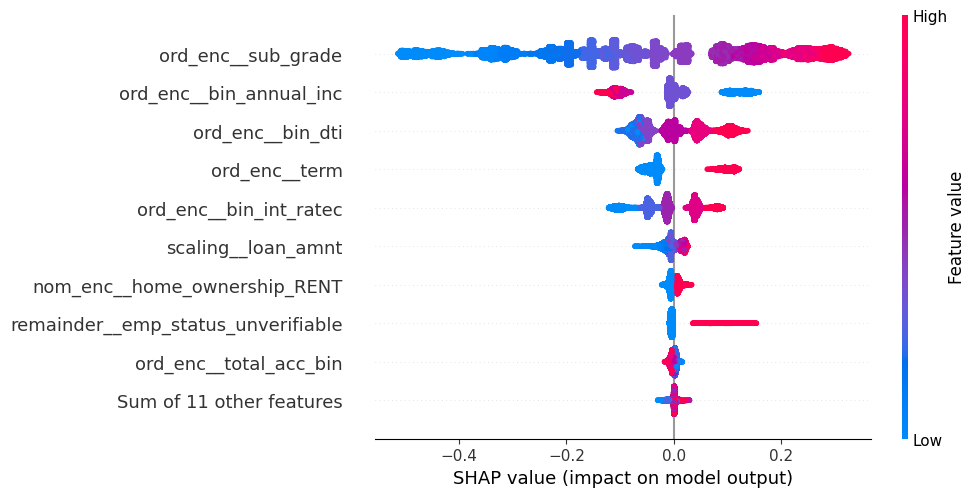

In [55]:
# Beeswarm plot 
shap.plots.beeswarm(shap_values_gb)

## GBM — SHAP Beeswarm Plot (Summary)

- **sub_grade** — widest spread of any feature — blue dots
  (low sub_grade = Grade A) push strongly left (reduces default
  risk), red dots (high sub_grade = Grade G) push right
  (increases default risk) — perfectly confirms EDA monotonicity
- **bin_annual_inc** — blue (low income) pushes slightly right
  (higher default risk), red (high income) pushes left — negative
  relationship with default confirmed
- **bin_dti** — red (high DTI) pushes right, blue (low DTI)
  pushes left — higher debt burden increases default probability
- **term** — red (60-month) pushes right, blue (36-month) pushes
  left — longer term consistently increases default risk
- **bin_int_rate** — similar pattern to term, red high rate
  pushes right — but narrower spread than sub_grade confirming
  sub_grade absorbs most of the rate signal
- **emp_status_unverifiable** — red dots cluster on the right —
  unknown employment status consistently increases default risk,
  no blue dots on right side — clean one-directional signal
- **total_acc_bin** — all dots clustered at zero — confirms zero
  SHAP contribution, completely ignored by the model

 Waterfall plot for a single observation which is non default


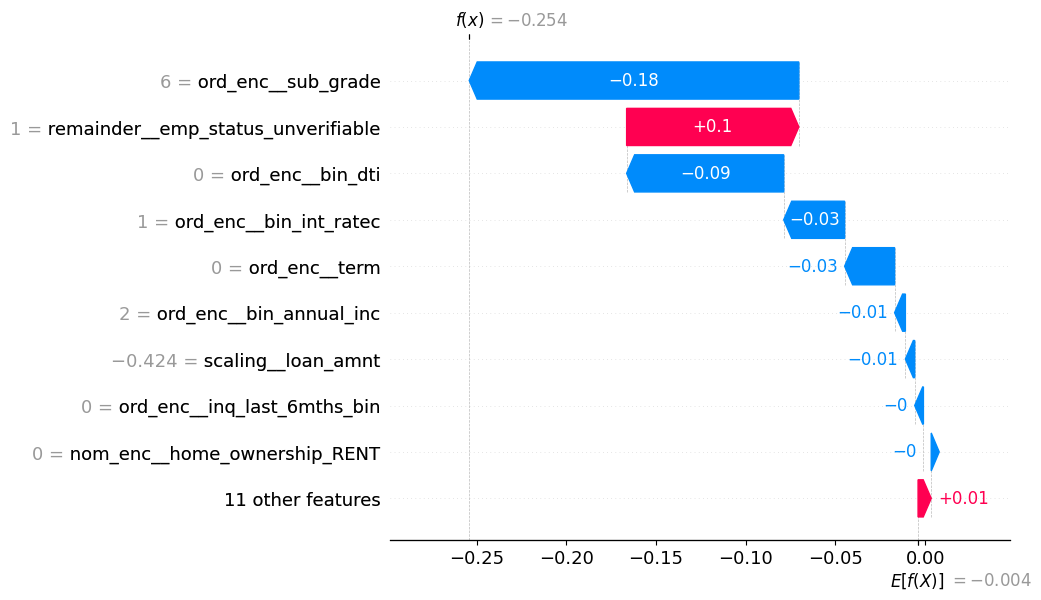

Default Prob=  0.43683920889452504


In [31]:
# plottin waterfall plot for 1 deafulter nad 1 non defauuletr obs 

# Waterfall plot1 - for non defaulters


gb.predict(X_test) 
# array([0, 1, 1, ..., 1, 1, 1], shape=(46058,))
# observation 0 = non defaulter
# observation 1 =  defaulter

print(' Waterfall plot for a single observation which is non default')
shap.plots.waterfall(shap_values_gb[0])
print("Default Prob= " , 1/(1+np.exp(-(-0.254))))

### SHAP Plot Interpretation
- Model output: f(x) = -0.254 (log-odds), baseline E[f(X)] = -0.004  
- Probability: ≈ 0.44 after sigmoid  
- Key impacts:
  - sub_grade (6) → −0.18 (lowers risk most)  
  - emp_status_unverifiable (1) → +0.10 (raises risk)  
  - bin_dti (0) → −0.09 (lowers risk)  
  - int_ratec (1), term (0) → −0.03 each  
  - Other features → small effects (±0.01)  
- **Takeaway**: Sub-grade strongly reduces risk, unverifiable employment increases it; overall probability ~44%.


 Waterfall plot for a single observation which is  default


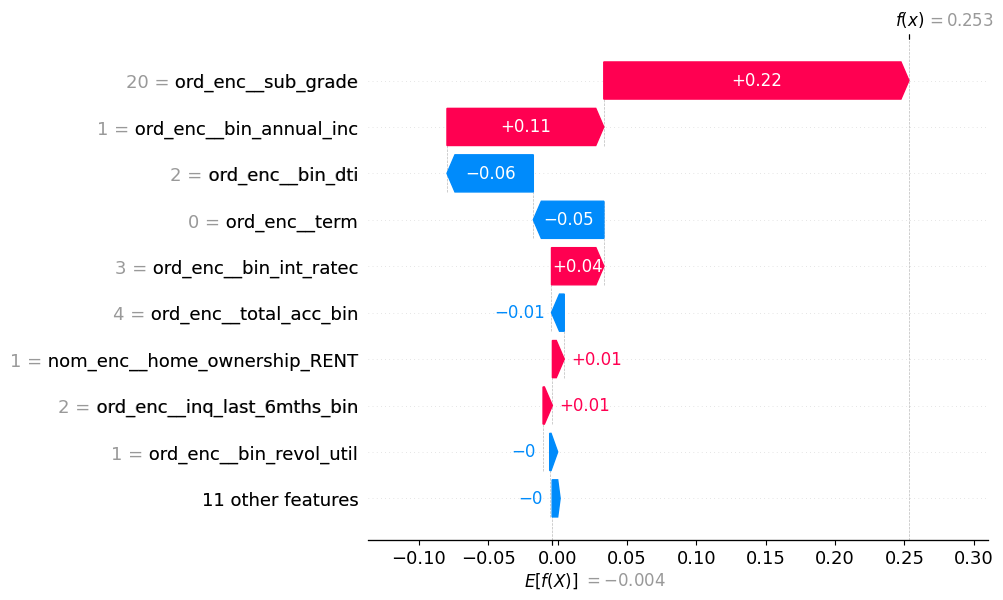

Default Prob=  0.5629147648722987


In [ ]:
# Waterfall plot1 - for defaulters

print(' Waterfall plot for a single observation which is  default')
shap.plots.waterfall(shap_values_gb[1])
print("Default Prob= " , 1/(1+np.exp(-(0.253))))

### SHAP Waterfall Interpretation
- Model output: f(x) = 0.253 (log-odds), baseline E[f(X)] = -0.004  
- Probability: ≈ 0.56 after sigmoid  
- Key impacts:
  - sub_grade (20) → +0.22 (strongly raises risk)  
  - annual_inc (1) → +0.11 (raises risk)  
  - dti (2) → −0.06 (lowers risk)  
  - term (0) → −0.05 (lowers risk)  
  - int_ratec (3) → +0.04 (raises risk)  
  - Other features → small effects (±0.01)  
- **Takeaway**: Sub-grade and income push risk higher; dti and term reduce risk; overall default probability ~56%.


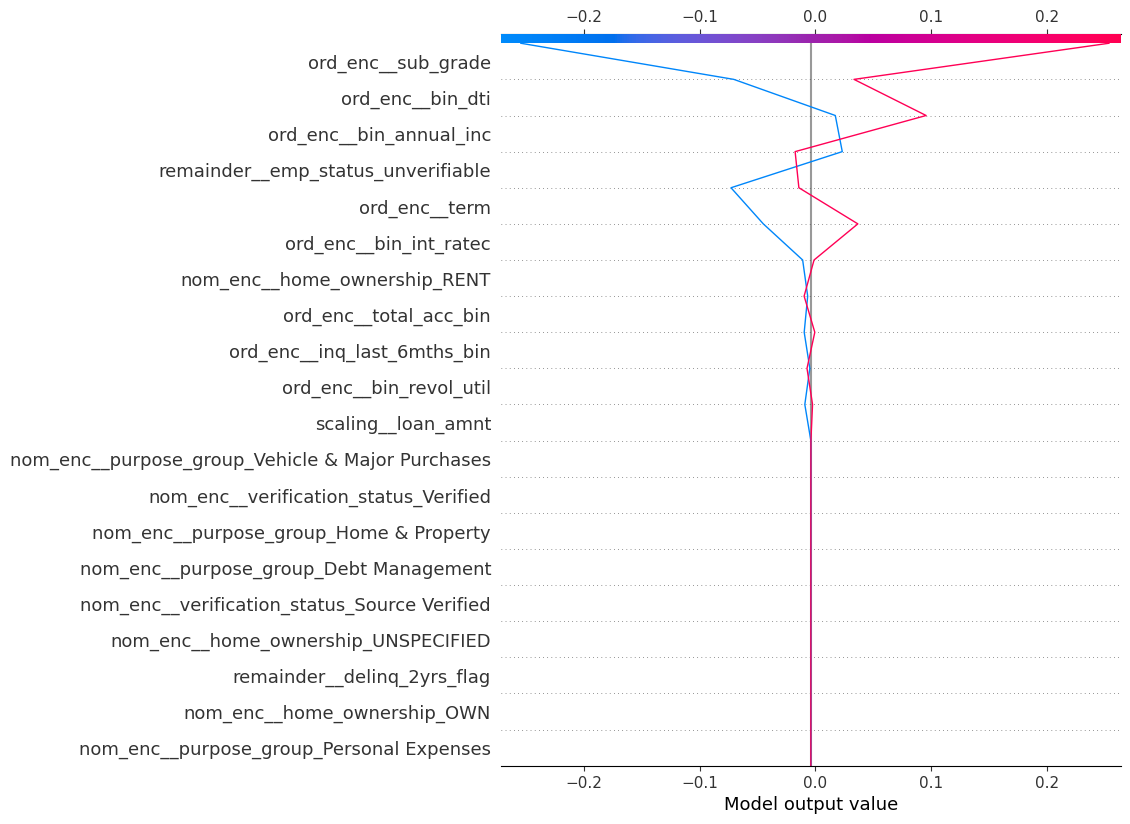

In [ ]:
# Decision plot 
shap.plots.decision(base_value = shap_values_gb.base_values[0],
                    shap_values = shap_values_gb.values[:2],
                    feature_names = X_test.columns.tolist())

In [80]:
X_test.sample()


,ord_enc__term,ord_enc__sub_grade,ord_enc__inq_last_6mths_bin,ord_enc__total_acc_bin,ord_enc__bin_annual_inc,ord_enc__bin_int_ratec,ord_enc__bin_dti,ord_enc__bin_revol_util,nom_enc__home_ownership_OWN,nom_enc__home_ownership_RENT,nom_enc__home_ownership_UNSPECIFIED,nom_enc__verification_status_Source Verified,nom_enc__verification_status_Verified,nom_enc__purpose_group_Debt Management,nom_enc__purpose_group_Home & Property,nom_enc__purpose_group_Personal Expenses,nom_enc__purpose_group_Vehicle & Major Purchases,scaling__loan_amnt,remainder__delinq_2yrs_flag,remainder__emp_status_unverifiable
44831,0.0,9.0,1.0,0.0,2.0,2.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.54355,0.0,0.0


Categories = ['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']


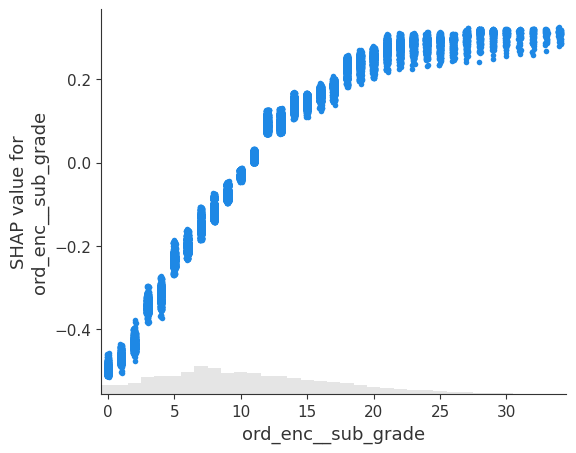

In [81]:
# Dependence — sub_grade


print(f'Categories = {preprocessing.named_transformers_['ord_enc'].categories_[1]}')
shap.plots.scatter(shap_values_gb[:, "ord_enc__sub_grade"])

## GBM — SHAP Dependence Plot: sub_grade

- **X-axis:** OrdinalEncoded sub_grade value
  (0 = A1 safest → 34 = G5 riskiest)
- **Y-axis:** SHAP value — how much sub_grade alone
  pushes the prediction toward or away from default

### Key Observations
- **A1-A5 (0-4):** SHAP values around -0.45 to -0.40 —
  Grade A borrowers strongly push prediction away from
  default — safest signal in the entire model
- **B1-C5 (5-14):** Smooth monotonic increase from -0.25
  to 0.0 — transition zone, model becomes increasingly
  uncertain about these borrowers
- **D1 onwards (15+):** SHAP crosses zero — sub_grade
  now actively pushes prediction toward default
- **E1-G5 (20-34):** SHAP plateaus around +0.25 to +0.30
  — riskiest borrowers, model is consistently confident
  about default prediction
- **Perfectly monotonic** — not a single reversal across
  all 35 sub-grades — strongest evidence that the model
  learned the correct risk ordering from the data
- **Plateau at high end** — G-tier borrowers cluster
  tightly, model treats them as equally high risk
  regardless of exact sub-grade within G

In [84]:
preprocessing.named_transformers_['ord_enc'].categories_

[array([' 36 months', ' 60 months'], dtype=object),
 array(['A1', 'A2', 'A3', 'A4', 'A5', 'B1', 'B2', 'B3', 'B4', 'B5', 'C1',
        'C2', 'C3', 'C4', 'C5', 'D1', 'D2', 'D3', 'D4', 'D5', 'E1', 'E2',
        'E3', 'E4', 'E5', 'F1', 'F2', 'F3', 'F4', 'F5', 'G1', 'G2', 'G3',
        'G4', 'G5'], dtype=object),
 array(['0', '0-1', '1-2', '2+'], dtype=object),
 array(['0-10', '10-16', '16-20', '20-26', '26-35', '35+'], dtype=object),
 array(['<18K', '18K-40K', '40K-80K', '80K-120K', '>120K'], dtype=object),
 array(['<8%', '8-12%', '12-15%', '15-21%', '21-24%', '>24%'], dtype=object),
 array(['<5', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '>35'],
       dtype=object),
 array(['<20%', '20-40%', '40-60%', '60-80%', '80-100%', '>100%'],
       dtype=object)]

Categories of Int_rate = ['<8%' '8-12%' '12-15%' '15-21%' '21-24%' '>24%']


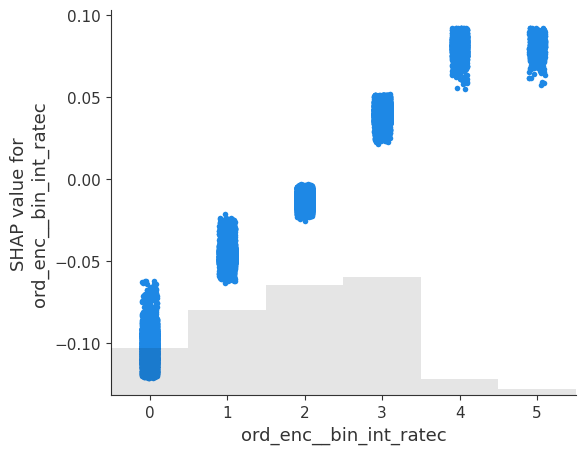

In [90]:
# Dependence — int_rate
print(f'Categories of Int_rate = {preprocessing.named_transformers_['ord_enc'].categories_[5]}')
shap.plots.scatter(shap_values_gb[:, "ord_enc__bin_int_ratec"])

## GBM — SHAP Dependence Plot: bin_int_rate

- **X-axis:** OrdinalEncoded bin_int_rate
  (0 = <8% → 5 = >24%)
- **Y-axis:** SHAP value — how much bin_int_rate alone
  pushes prediction toward or away from default
- **Categories:** <8%, 8-12%, 12-15%, 15-21%, 21-24%, >24%

### Key Observations
- **<8% (0):** SHAP around -0.08 to -0.12 — very low
  interest rate strongly pushes prediction away from
  default — safest borrowers, bank priced them correctly
- **8-12% (1):** SHAP around -0.03 to -0.07 — still
  negative but signal weakens — moderate risk zone
- **12-15% (2):** SHAP crosses zero — interest rate
  bracket is now neutral, neither protecting nor
  increasing default probability
- **15-21% (3):** SHAP around +0.02 to +0.05 — rate
  now actively pushing toward default
- **21-24% and >24% (4,5):** SHAP jumps to +0.07 to
  +0.09 — high rate brackets consistently increase
  default probability — model correctly identifies
  high-rate loans as high risk
- **Perfectly monotonic across all 6 brackets** —
  confirms binning decision was correct, each bracket
  carries meaningfully different risk signal
- **Discrete clusters** — because feature is binned,
  all borrowers in same bracket get same SHAP value —
  clean separation between risk tiers

Categories of Term = [' 36 months' ' 60 months']


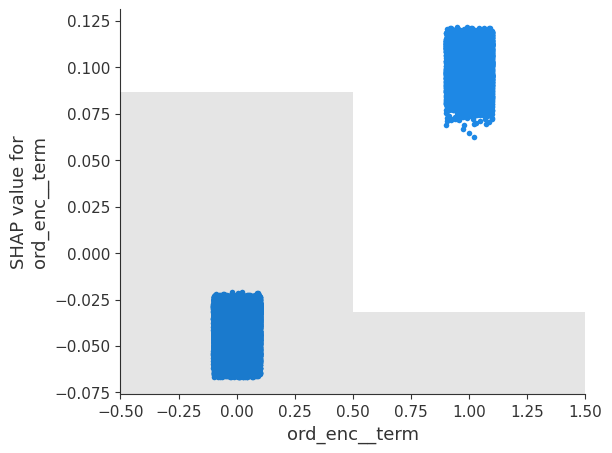

In [92]:
# Dependence — Term
print(f'Categories of Term = {preprocessing.named_transformers_['ord_enc'].categories_[0]}')
shap.plots.scatter(shap_values_gb[:, "ord_enc__term"])

## GBM — SHAP Dependence Plot: term

- **X-axis:** OrdinalEncoded term (0 = 36 months, 1 = 60 months)
- **Y-axis:** SHAP value — how much term alone pushes
  prediction toward or away from default
- **Categories:** 36 months, 60 months — binary feature

### Key Observations
- **36 months (0):** SHAP around -0.025 to -0.065 —
  shorter term consistently pushes prediction away
  from default — 36-month borrowers are safer
- **60 months (1):** SHAP around +0.075 to +0.125 —
  longer term strongly pushes prediction toward default
- **Gap between clusters is large** — approximately
  0.15 SHAP units separate the two groups — term is
  a powerful binary switch in the model
- **Tight clusters within each term** — all 36-month
  borrowers get nearly identical SHAP values, same for
  60-month — term alone carries a clean, consistent
  signal regardless of other features
- **Confirms EDA finding** — 60-month loans defaulted
  at 2× the rate of 36-month loans — SHAP quantifies
  exactly how much this duration difference impacts
  each individual prediction
- **No overlap between groups** — model has learned
  a hard boundary between the two terms

# LinearExplainer

In [102]:
df = pd.read_csv(r'C:\Users\Dev\OneDrive\Desktop\data\phase3_modelling\modelling_ready_data.csv').iloc[:,1:]
from sklearn.model_selection import train_test_split
X_train,X_t, y_train , y_t =  train_test_split(df.drop('loan_status',axis=1), df['loan_status'], stratify=df['loan_status'],
                                                     test_size=0.2, random_state=45)

In [103]:
X_train = pd.DataFrame(preprocessing.transform(X_train),columns=preprocessing.get_feature_names_out())

In [108]:
masker = shap.maskers.Independent(X_train ,max_samples=184230)

explainer = shap.LinearExplainer(lr,masker)
shap_values_lr = explainer(X_test)

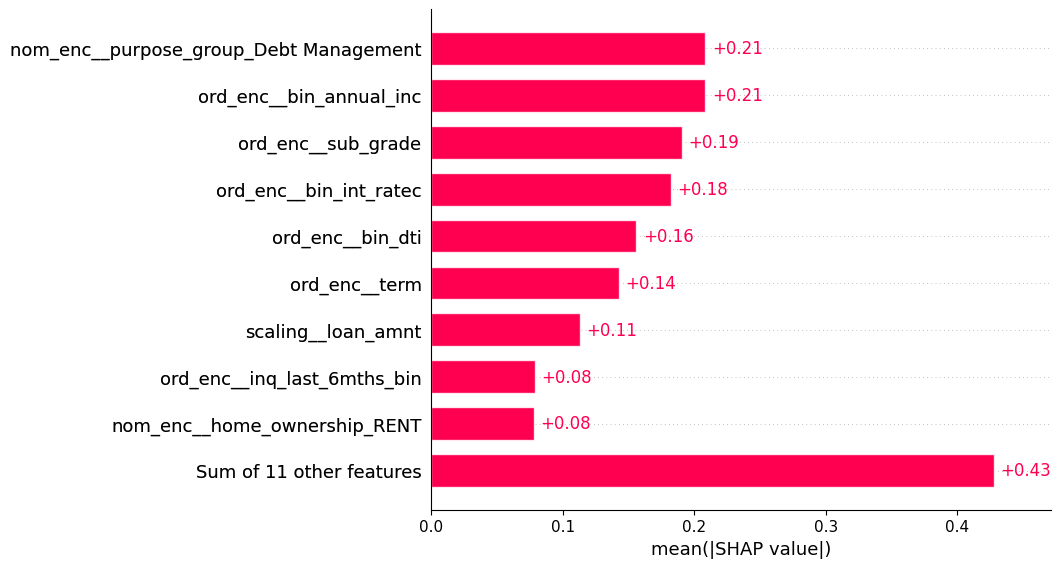

In [116]:
# Bar plot 
shap.plots.bar(shap_values_lr, max_display=10)

## LR — SHAP Bar Plot (Global Importance)
- **purpose_group_Debt Management and bin_annual_inc (0.21)**
  joint top — LR distributes importance far more evenly than GBM
- **sub_grade and bin_int_rate (0.18-0.19)** — strong but not
  dominant, unlike GBM where sub_grade alone = 0.19
- **Sum of 11 other features (0.43)** — LR uses many features
  collectively, no single feature dominates

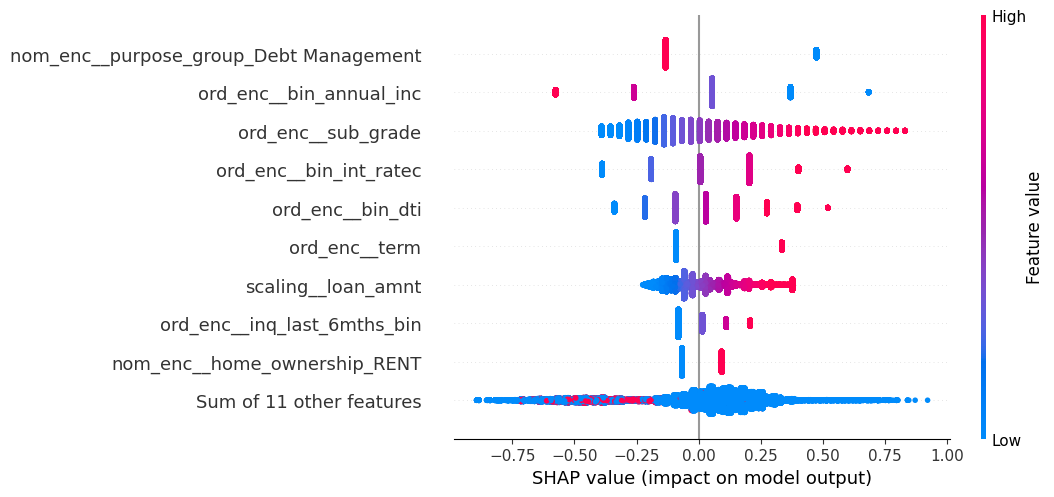

In [117]:
# Beeswarm plot 
shap.plots.beeswarm(shap_values_lr)

## LR — SHAP Beeswarm Plot
- **purpose_group_Debt Management** — red (= Debt Management loan)
  pushes left — reduces default risk, consistent with EDA
- **bin_annual_inc** — blue (low income) pushes right, red pushes
  left — income negatively associated with default
- **sub_grade** — red dots spread right — higher grade = higher risk
- **loan_amnt** — widest horizontal spread — large loans push both
  directions, model uncertain about loan size signal
- **Sum of other features** — massive blue cluster on left —
  collectively many features reduce default probability

 Waterfall plot for a single observation which is non default


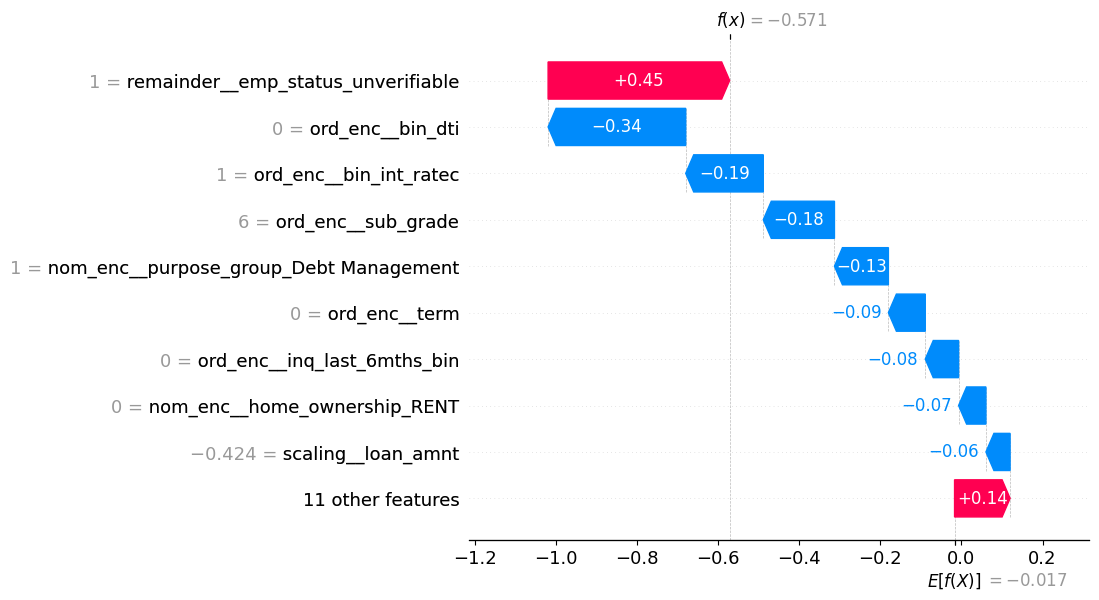

Default Prob=  0.36100611210359496


In [120]:

# Waterfall plot1 - for non defaulters


lr.predict(X_test) 
# array([0, 1, 1, ..., 1, 1, 1], shape=(46058,))
# # observation 0 = non defaulter
# # observation 1 =  defaulter

print(' Waterfall plot for a single observation which is non default')
shap.plots.waterfall(shap_values_lr[0])
print("Default Prob= " , 1/(1+np.exp(-(-0.571))))

## LR — Waterfall: Non-Defaulter (f(x) = -0.571)
- **emp_status_unverifiable = 1 (+0.45)** — unknown employment
  status pushes strongly toward default — biggest positive push
- **bin_dti = 0 (-0.34)** — very low DTI strongly protects
  against default — biggest protective factor
- **bin_int_rate = 1 (-0.19), sub_grade = 6 (-0.18)** —
  low-medium grade and rate push away from default
- **Final prediction -0.571** — model confidently predicts
  Not Defaulter despite unverifiable employment

 Waterfall plot for a single observation which is non default


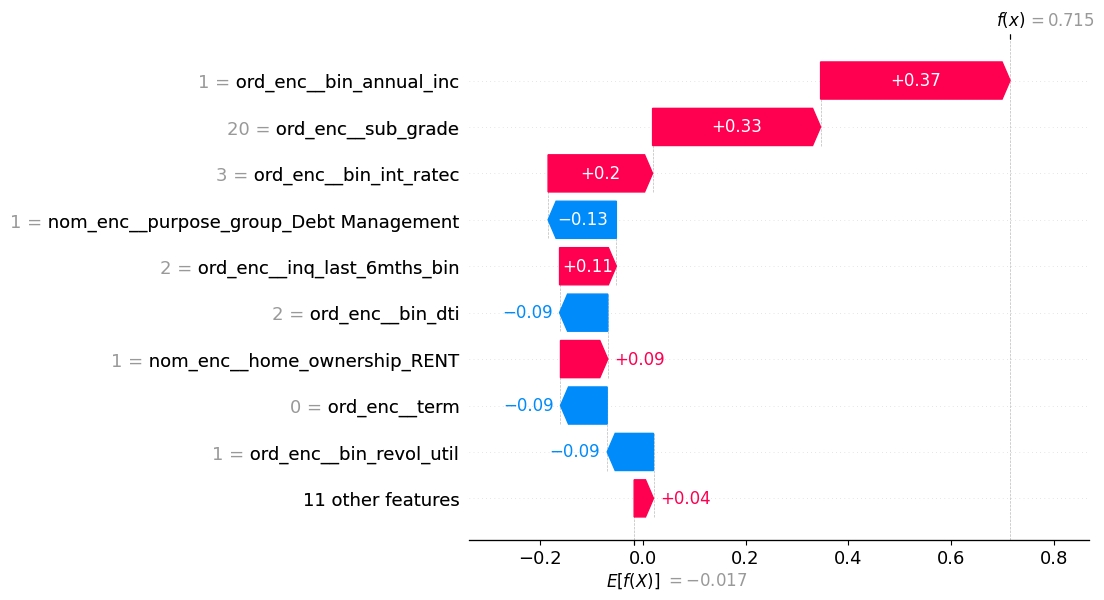

Default Prob=  0.6715050342254059


In [122]:

# Waterfall plot1 - for non defaulters


lr.predict(X_test) 
# array([0, 1, 1, ..., 1, 1, 1], shape=(46058,))
# # observation 0 = non defaulter
# # observation 1 =  defaulter

print(' Waterfall plot for a single observation which is non default')
shap.plots.waterfall(shap_values_lr[1])
print("Default Prob= " , 1/(1+np.exp(-(0.715))))

## LR — Waterfall: Defaulter (f(x) = 0.715)
- **bin_annual_inc = 1 (+0.37)** — low income bracket is
  the single strongest push toward default for this borrower
- **sub_grade = 20 (+0.33)** — E1 grade confirms high risk
- **bin_int_rate = 3 (+0.20)** — 15-21% rate adds further risk
- **purpose_group_Debt Management (-0.13)** — only protective
  factor, partially offsets the risk
- **Final prediction 0.715** — model confidently flags as defaulter

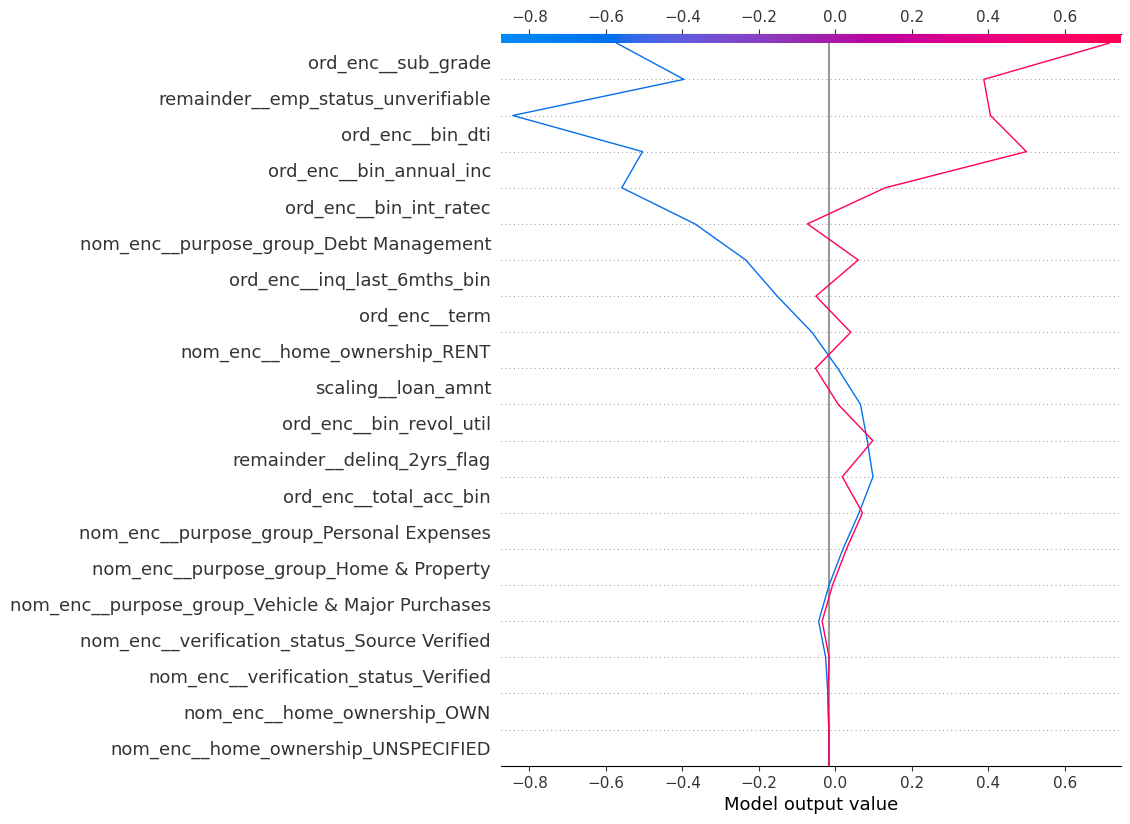

In [ ]:
shap.plots.decision(base_value = shap_values_lr.base_values[0],
                    shap_values = shap_values_lr.values[:2],
                    feature_names = X_test.columns.tolist())

Categories = ['A1' 'A2' 'A3' 'A4' 'A5' 'B1' 'B2' 'B3' 'B4' 'B5' 'C1' 'C2' 'C3' 'C4'
 'C5' 'D1' 'D2' 'D3' 'D4' 'D5' 'E1' 'E2' 'E3' 'E4' 'E5' 'F1' 'F2' 'F3'
 'F4' 'F5' 'G1' 'G2' 'G3' 'G4' 'G5']


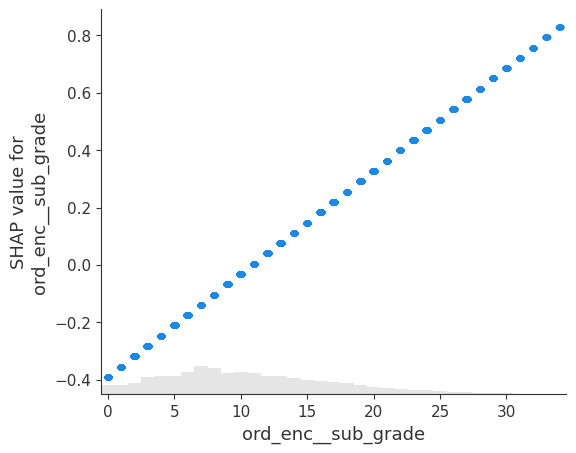

In [123]:
# Dependence — sub_grade


print(f'Categories = {preprocessing.named_transformers_['ord_enc'].categories_[1]}')
shap.plots.scatter(shap_values_lr[:, "ord_enc__sub_grade"])

## LR — Dependence Plot: sub_grade
- **Perfectly linear** — unlike GBM which plateaued at G tier,
  LR shows a straight line from -0.4 (A1) to +0.8 (G5)
- No plateau — LR treats every sub_grade step as equally
  meaningful, cannot learn the diminishing returns at extremes
- Range much wider than GBM (-0.4 to +0.8 vs -0.5 to +0.3)
  — LR relies more heavily on sub_grade for extreme predictions

Categories of Int_rate = ['<8%' '8-12%' '12-15%' '15-21%' '21-24%' '>24%']


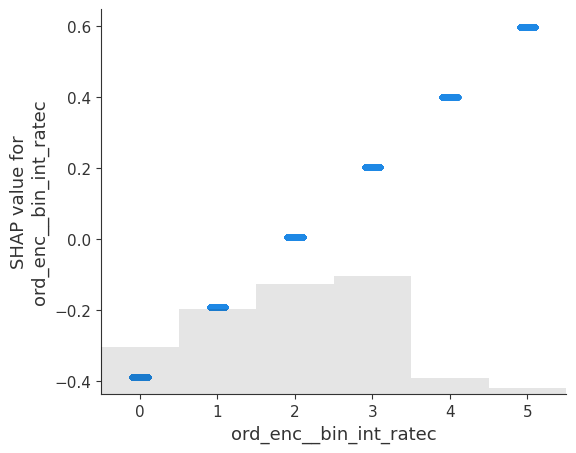

In [124]:
# Dependence — int_rate
print(f'Categories of Int_rate = {preprocessing.named_transformers_['ord_enc'].categories_[5]}')
shap.plots.scatter(shap_values_lr[:, "ord_enc__bin_int_ratec"])

## LR — Dependence Plot: bin_int_rate
- **Discrete jumps** — 6 clean steps from -0.4 (<8%) to +0.6 (>24%)
- Much larger SHAP range than GBM (-0.4 to +0.6 vs -0.12 to +0.09)
- LR assigns far more weight to interest rate than GBM does —
  key difference between the two models
- Perfectly monotonic — each bracket meaningfully higher than previous

Categories of Term = [' 36 months' ' 60 months']


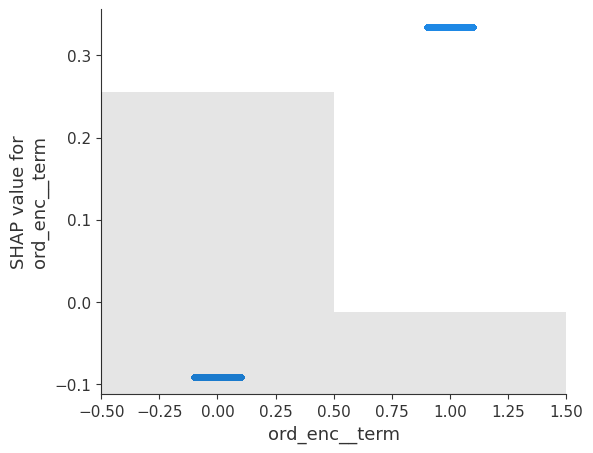

In [125]:
# Dependence — Term
print(f'Categories of Term = {preprocessing.named_transformers_['ord_enc'].categories_[0]}')
shap.plots.scatter(shap_values_lr[:, "ord_enc__term"])

## LR — Dependence Plot: term
- **36 months (0): SHAP = -0.10** — reduces default risk
- **60 months (1): SHAP = +0.33** — strongly increases default risk
- Larger gap than GBM (-0.04 vs +0.10) — LR weights term
  more aggressively than GBM
- Same directional finding — confirms term is a genuine
  risk signal across both models

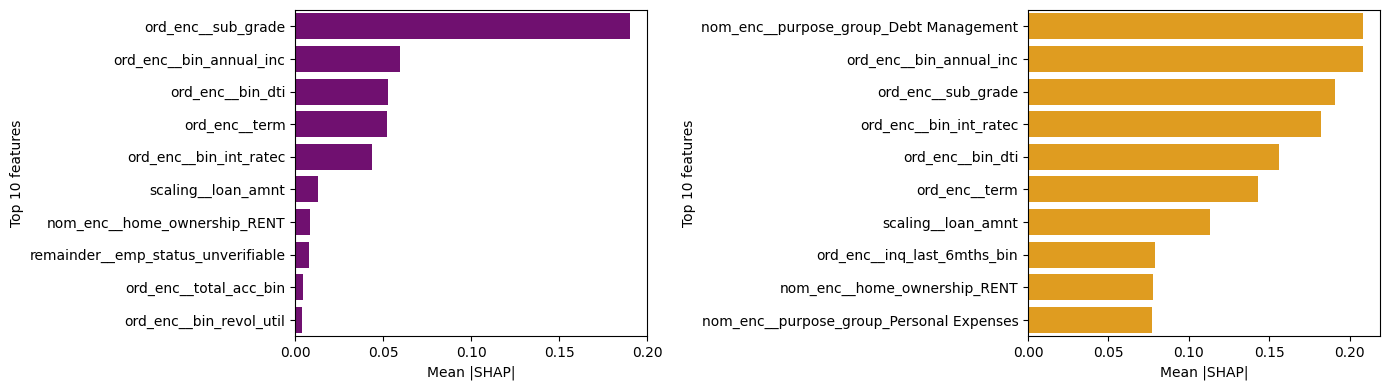

In [160]:
# Plotting the top Shap Absolute features off gradient boosting logistic regression side by side

# For this creating two series for gradient boosting top features
#  And their mean absolute SHAP values and the same for logistic regression

gb_shap_features = pd.Series(np.abs(shap_values_gb.values).mean(axis=0),
                            index = X_test.columns).sort_values(ascending=False)

lr_shap_features = pd.Series(np.abs(shap_values_lr.values).mean(axis=0),
                            index = X_test.columns).sort_values(ascending=False)



plt.figure(figsize = (14,4))
plt.subplot(1,2,1)
sns.barplot(gb_shap_features.iloc[:10],
            orient='h',
            color = 'purple')
plt.xlabel('Mean |SHAP|')
plt.ylabel('Top 10 features')

plt.subplot(1,2,2)
sns.barplot(lr_shap_features.iloc[:10],
            orient='h',
            color= 'orange')
plt.xlabel('Mean |SHAP|')
plt.ylabel('Top 10 features')

plt.tight_layout()


## Side-by-Side SHAP Comparison — GBM vs LR

- **GBM concentrates on sub_grade (0.19)** — one dominant feature,
  all others far behind. Tree model learned to rely on the
  single strongest signal
- **LR distributes evenly** — top 9 features all within 0.08-0.21
  range. Linear model must use all features proportionally
- **Both agree on top features** — sub_grade, bin_annual_inc,
  bin_int_rate, bin_dti, term appear in top 6 of both models —
  confirms these are genuine default signals not model artifacts
- **Key difference** — purpose_group_Debt Management ranks 1st
  in LR but absent from GBM top 10 — LR captures loan purpose
  signal that GBM absorbs through sub_grade interaction
- **loan_amnt** — appears in both but with very different weight,
  LR treats it as more important than GBM does

## Phase 5 — SHAP Explainability Analysis

### Models Explained
- **Gradient Boosting** — TreeExplainer (exact Shapley values)
- **Logistic Regression** — LinearExplainer with Independent masker

---

### GBM — Key SHAP Findings

**Global Importance:**
- sub_grade (0.19) dominates — 3× more important than any other feature
- bin_annual_inc, bin_dti, term all equal at 0.05-0.06 — second tier
- bin_int_rate (0.04) lower than expected — GBM routes rate signal through sub_grade
- total_acc_bin = 0.00 — completely ignored by model

**Directional Signals (Beeswarm):**
- Grade A (blue) → strongly reduces default risk | Grade G (red) → strongly increases
- Low income (blue) → increases risk | High income (red) → reduces risk
- 60-month term (red) → increases risk | 36-month (blue) → reduces risk
- Unknown employment (red) → consistently increases risk

**Individual Predictions:**
- Non-Defaulter: f(x) = -0.254, Probability = 44% — Grade B and low DTI protect despite unverifiable employment
- Defaulter: f(x) = +0.253, Probability = 56% — Grade E and low income drive default despite 36-month term

**Dependence Plots — All Perfectly Monotonic:**
- sub_grade: -0.45 (A1) → +0.25 (G5), plateaus at G tier
- bin_int_rate: -0.10 (<8%) → +0.09 (>24%), discrete clean steps
- term: -0.04 (36m) → +0.10 (60m), hard binary boundary

---

### LR — Key SHAP Findings

**Global Importance:**
- No single dominant feature — top 9 all within 0.08-0.21 range
- purpose_group_Debt Management (0.21) ranks 1st — LR uses purpose directly
- bin_annual_inc (0.21) joint top — income weighted more heavily than in GBM
- sub_grade (0.19) strong but not dominant

**Individual Predictions (same borrowers as GBM):**
- Non-Defaulter: f(x) = -0.571, Probability = 36% — LR more conservative than GBM (44%)
- Defaulter: f(x) = +0.715, Probability = 67% — LR more aggressive than GBM (56%)

**Dependence Plots vs GBM:**
- sub_grade: perfectly linear -0.4 to +0.8 — no plateau, LR cannot learn diminishing returns
- bin_int_rate: -0.4 to +0.6 — much wider range than GBM (-0.12 to +0.09)
- term: -0.10 (36m) → +0.33 (60m) — larger gap than GBM

---

### GBM vs LR — Side-by-Side Comparison

| Feature | GBM | LR | Agreement |
|---|---|---|---|
| sub_grade | 1st (0.19) | 3rd (0.19) | ✅ Both top 3 |
| bin_annual_inc | 2nd (0.06) | 2nd (0.21) | ✅ Both top 3 |
| bin_int_rate | 5th (0.04) | 4th (0.18) | ✅ Both top 5 |
| bin_dti | 3rd (0.05) | 5th (0.16) | ✅ Both top 6 |
| term | 4th (0.05) | 6th (0.14) | ✅ Both top 6 |
| purpose_group_Debt Mgmt | Absent | 1st (0.21) | ❌ LR only |
| loan_amnt | 0.01 | 0.11 | ❌ LR weights higher |

**Key insight:** Both models agree on the top 5 risk features —
confirming these are genuine data signals not model artifacts.
GBM concentrates on sub_grade; LR distributes evenly across all features.

---

### Overall Conclusion
- All EDA findings confirmed by SHAP — no contradictions or surprises
- sub_grade is the universal dominant signal across both models
- The two-model approach is validated — GBM for calibrated scoring,
  LR for transparent regulatory explanation
- Waterfall plots provide individual-level audit-ready explanations
  for any loan decision